In [1]:
import omicverse as ov
ov.plot_set()

2024-11-25 13:59:27.701676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-25 13:59:27.732272: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-25 13:59:27.739233: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-25 13:59:29.226581: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata_count=ov.read('data/GC_ST/GAS_GC_RAW_velo.h5ad')
adata_count

AnnData object with n_obs × n_vars = 93845 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    layers: 

In [3]:
adata_count.obs['CancerStage'].unique()

['No', 'T1', 'T3', 'T4', 'T2']
Categories (5, object): ['No', 'T1', 'T2', 'T3', 'T4']

In [4]:
import scanpy as sc
sc.pp.normalize_total(
    adata_count,
    target_sum=50*1e4,
    exclude_highly_expressed=True,
    max_fraction=0.2,
)
sc.pp.log1p(adata_count)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-6', 'IGKV3-7', 'IGKV1-8', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1-33', 'IGKV1-39', 'IGKV2D-40', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-30', 'IGKV2D-29', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'IGKV1D-13', 'IGKV1OR2-108', 'GHRL', 'SST', 'JCHAIN', 'MLN', 'PGC', 'DEFA6', 'DEFA5', 'LIPF', 'HBB', 'PGA3', 'FTH1', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'IGHV6-1', 'IGHV1-2', 'IGHV1-3', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV5-10-1', 'IGHV3-11', 'IGHV3-13', 'IGHV3-15', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV3-33', 'IGHV4-34', 'IGHV4-39', 'IGHV3-43', 'IGHV1-46', 'IGHV3-48', 'IGHV3-49', 'IGHV5-51', 'IGHV3-53', 'IGHV1-58', 'IG

In [5]:
adata_count.layers['normalized']=adata_count.X

In [7]:
def deg_clusters(adata,cluster_type,group_type,
                treatmentgroup,controlgroup,layer='normalized'):
    from tqdm import tqdm
    deg_results_dict={}
    adata.obs[cluster_type]=adata.obs[cluster_type].astype('category')
    for cluster in tqdm(adata.obs[cluster_type].cat.categories):
        adata_sub=adata[adata.obs[cluster_type]==cluster]
        test_adata=adata_sub
        dds=ov.bulk.pyDEG(test_adata.to_df(layer=layer).T)
        treatment_groups=test_adata.obs[test_adata.obs[group_type]==treatmentgroup].index.tolist()
        if len(treatment_groups)<=1:
            continue
        control_groups=test_adata.obs[test_adata.obs[group_type]==controlgroup].index.tolist()
        if len(control_groups)<=1:
            continue
        dds.result=dds.deg_analysis(treatment_groups,control_groups,method='ttest')
        dds.result=dds.result.loc[dds.result['BaseMean']>1]
        # -1 means automatically calculates
        dds.foldchange_set(fc_threshold=-1,
                           pval_threshold=0.05,
                           logp_max=10)
        deg_results_dict[cluster]=dds.result
    adata.uns['deg_clusters_dict']=deg_results_dict
    return deg_results_dict
deg_results_dict=deg_clusters(adata=adata_count,cluster_type='best_celltype',group_type='CancerStage',
                treatmentgroup='T1',controlgroup='No',layer='normalized')

  7%|▋         | 1/15 [00:01<00:24,  1.74s/it]

... Fold change threshold: 2.1169931888580322


 13%|█▎        | 2/15 [00:02<00:12,  1.04it/s]

... Fold change threshold: 1.5450010299682617


 20%|██        | 3/15 [00:04<00:18,  1.58s/it]

...

... Fold change threshold: 1.4625005722045898


 87%|████████▋ | 13/15 [00:12<00:02,  1.25s/it]

... Fold change threshold: 1.7099251747131348


100%|██████████| 15/15 [00:16<00:00,  1.11s/it]

... Fold change threshold: 1.8819730281829834


In [8]:
ov.utils.save(deg_results_dict,'result/deg_results_dict.pkl')

In [6]:
deg_results_dict=ov.utils.load('result/deg_results_dict.pkl')

In [7]:
adata=adata_count[adata_count.obs['CancerStage'].isin(['No','T1'])]

<AxesSubplot: title={'center': 'Group'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

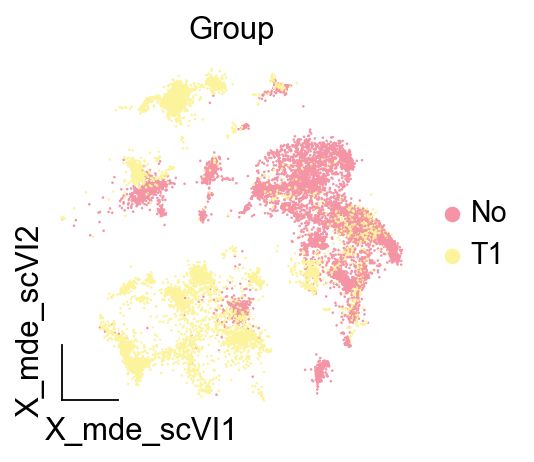

In [10]:
import matplotlib.pyplot as plt
fb=ov.pl.ForbiddenCity()
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['CancerStage'],
    title='Group',
    frameon='small',
    #ncols=1,
    palette=[
             fb.get_color(name='杨妃')['color_html'].values[0],
             fb.get_color(name='黄白游')['color_html'].values[0],],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

[<AxesSubplot: title={'center': 'Group'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>,
 <AxesSubplot: title={'center': 'MUC5AC'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>,
 <AxesSubplot: title={'center': 'JCHAIN'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>]

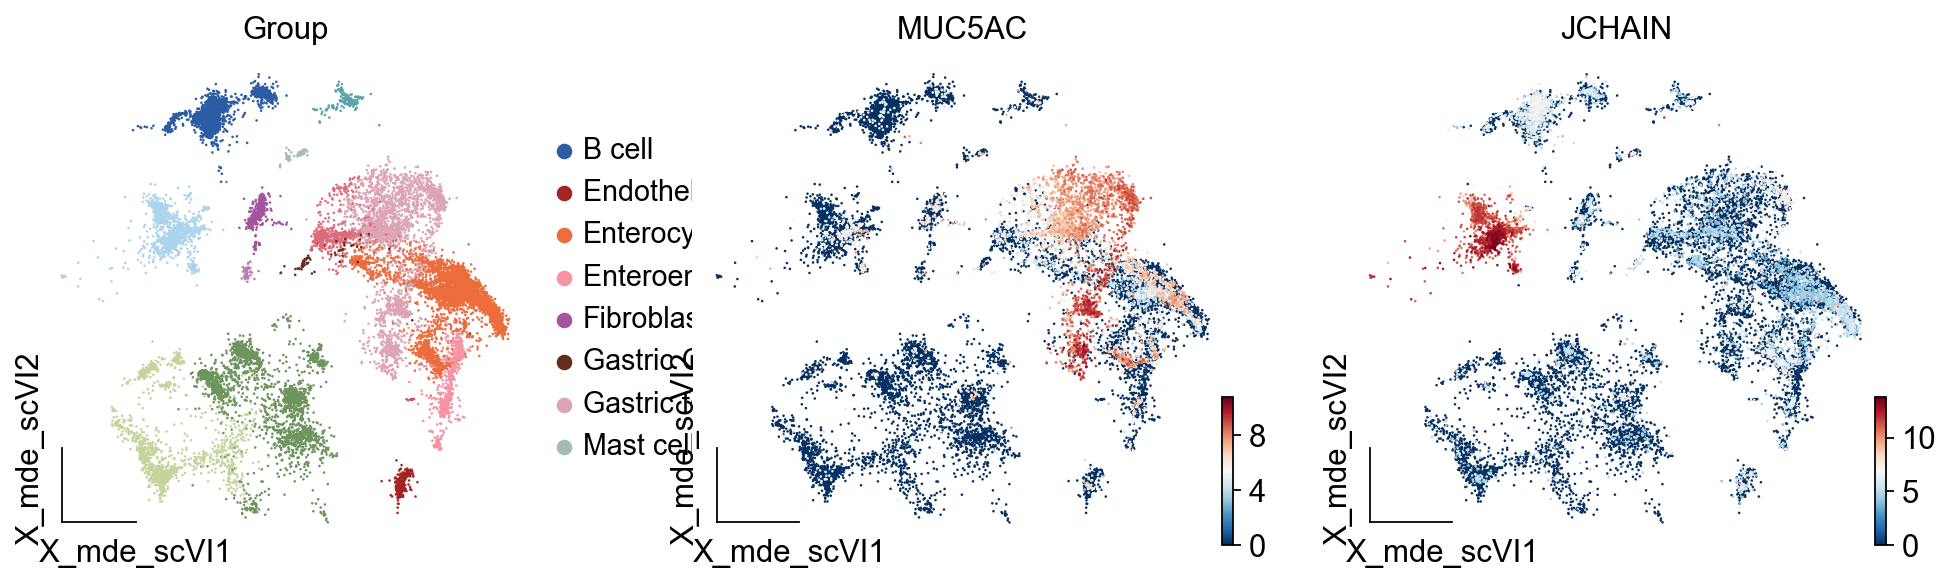

In [11]:
ov.utils.embedding(
    adata,
    basis="X_mde_scVI",
    color=['best_celltype','MUC5AC','JCHAIN'],
    title='Group',
    frameon='small',
    #ncols=1,
   # palette=[
    #         fb.get_color(name='杨妃')['color_html'].values[0],
     #        fb.get_color(name='黄白游')['color_html'].values[0],],
    #legend_loc='on data',
    #legend_fontsize=12,
    #ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

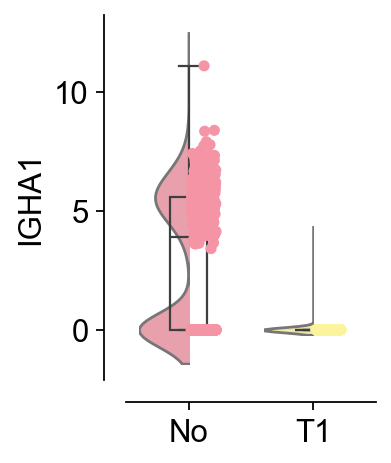

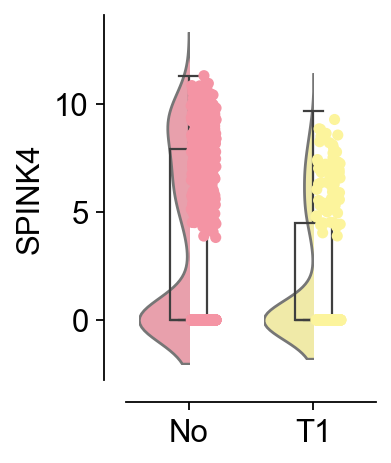

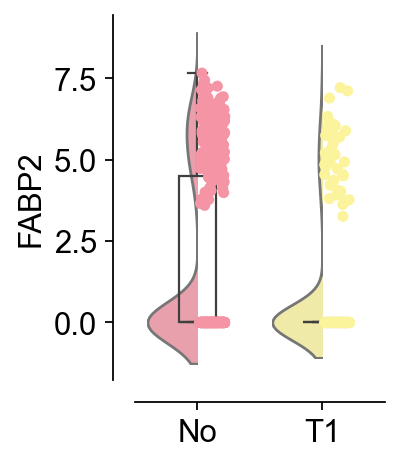

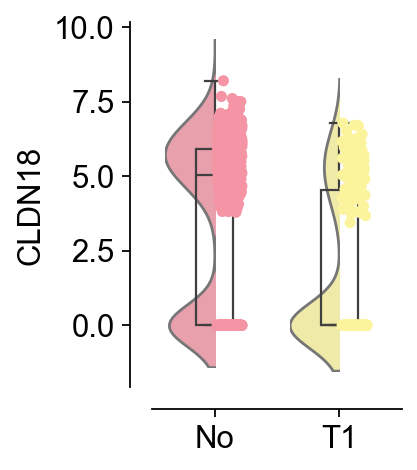

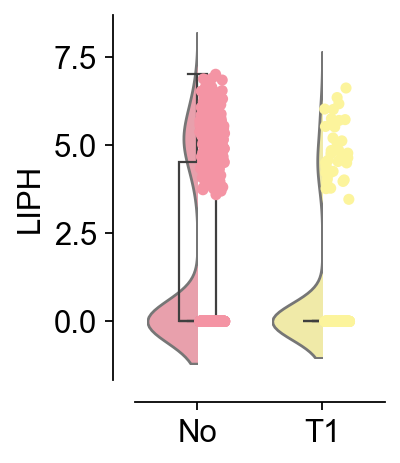

In [55]:
import matplotlib.pyplot as plt

ct='Enteroendocrine cell'
for gene in ['IGHA1', 'SPINK4', 'FABP2', 'CLDN18', 'LIPH']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

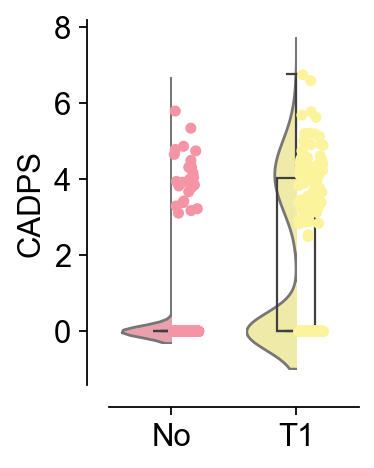

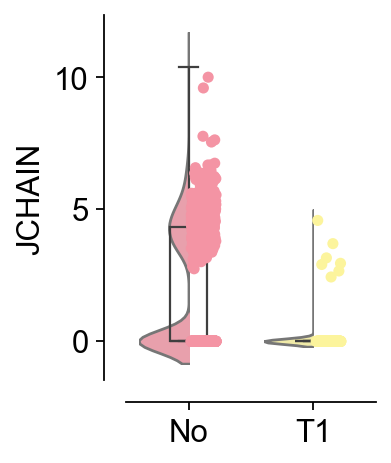

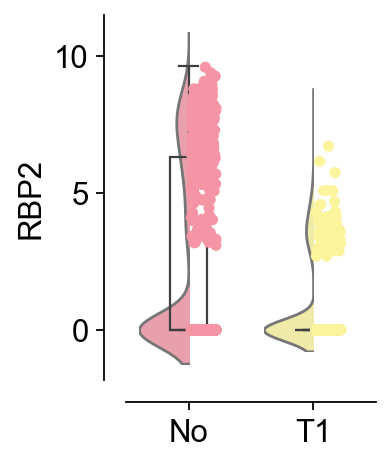

In [13]:
import matplotlib.pyplot as plt

ct='Enterocyte'
for gene in ['CADPS','JCHAIN','RBP2']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

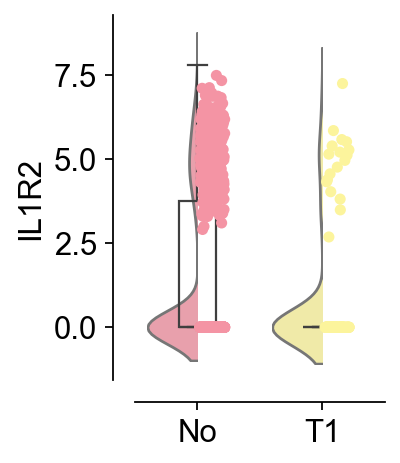

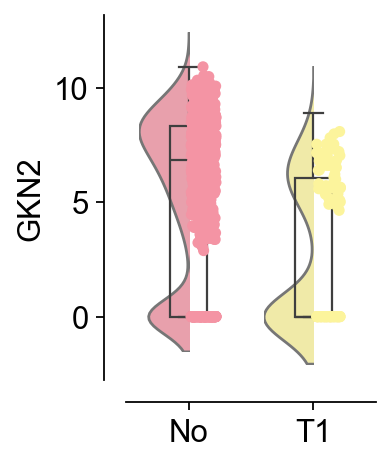

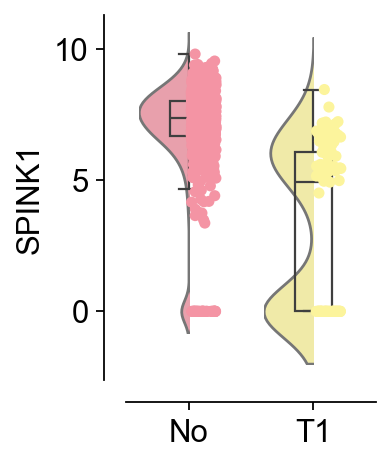

In [16]:
import matplotlib.pyplot as plt

ct='Gastric foveolar cell'
for gene in ['IL1R2','GKN2','SPINK1']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

In [36]:
ct='Plasma cell'
deg_results_dict[ct]['sig']='normal'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']>1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='up'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']<-1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='down'

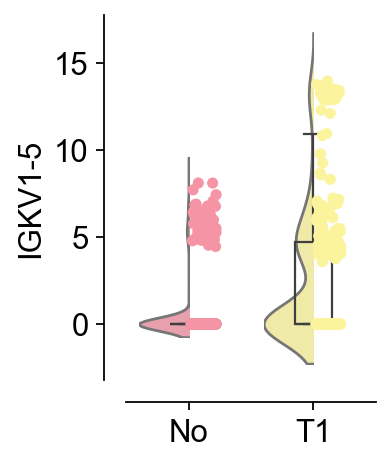

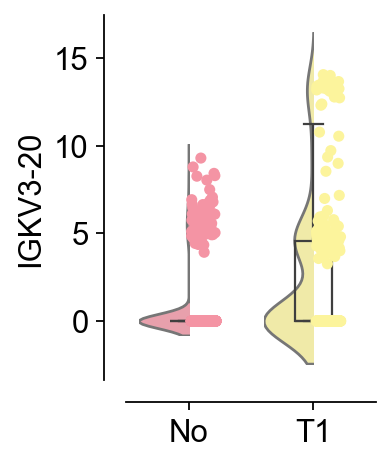

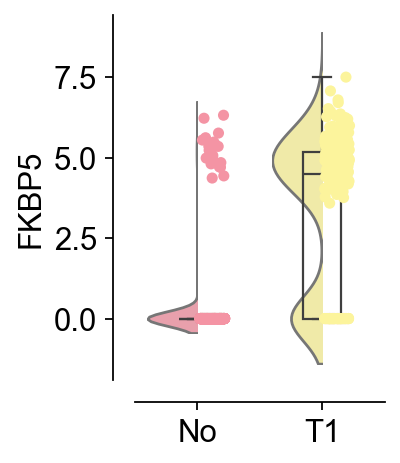

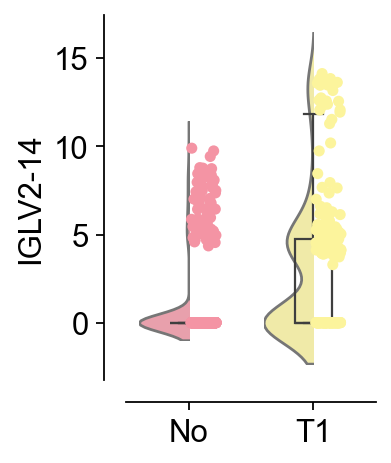

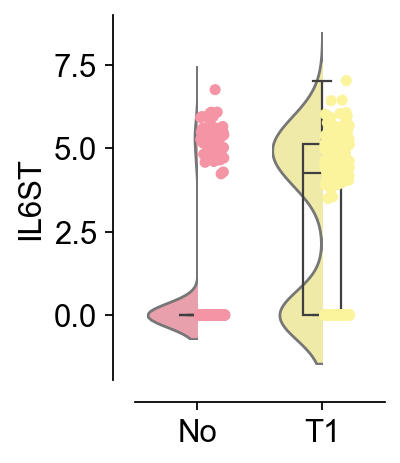

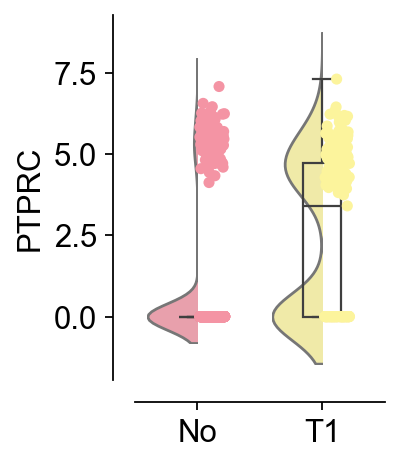

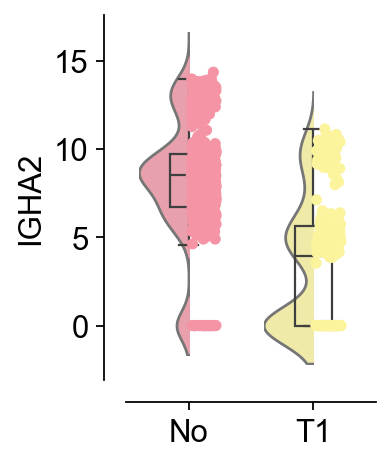

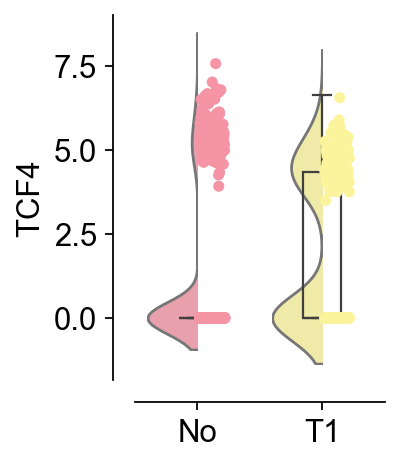

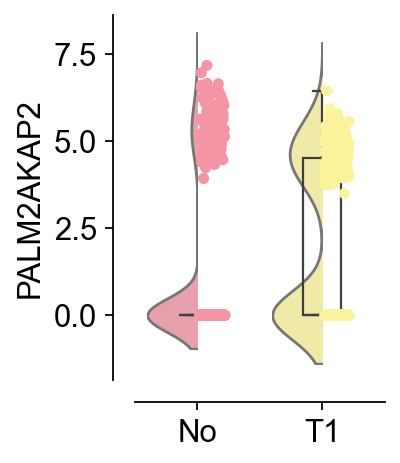

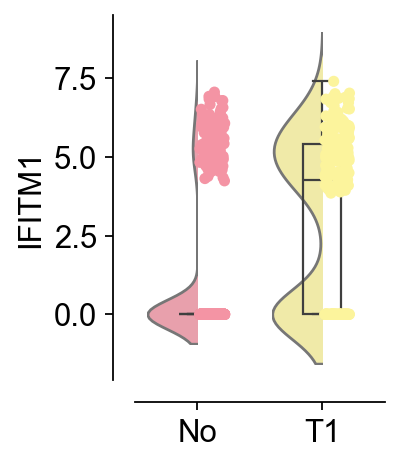

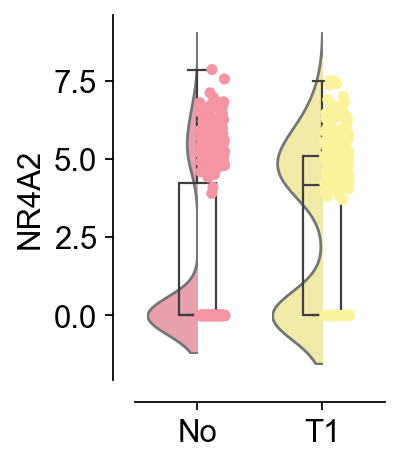

In [37]:
import matplotlib.pyplot as plt

ct='Plasma cell'
for gene in ['IGKV1-5', 'IGKV3-20', 'FKBP5', 'IGLV2-14', 'IL6ST',
            'PTPRC', 'IGHA2', 'TCF4', 'PALM2AKAP2', 'IFITM1', 'NR4A2']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

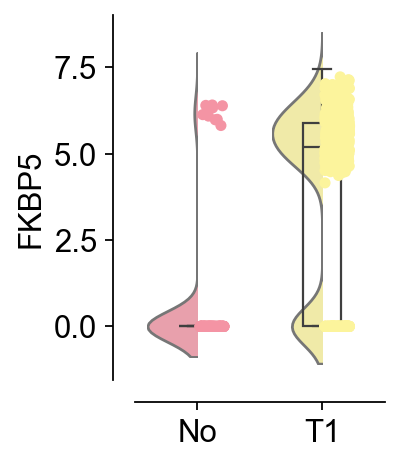

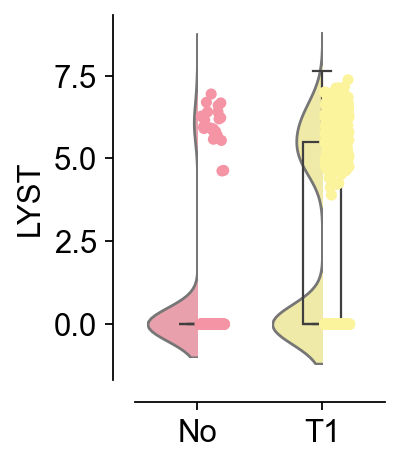

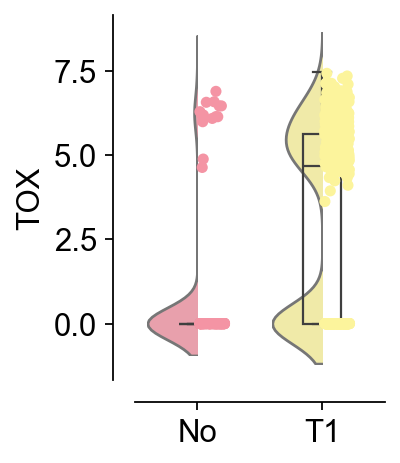

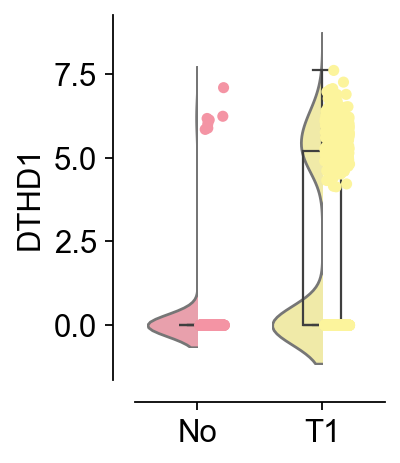

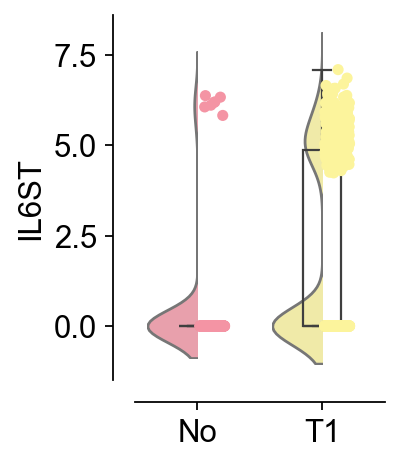

In [39]:
import matplotlib.pyplot as plt

ct='T CD8+'
for gene in ['FKBP5', 'LYST', 'TOX', 'DTHD1', 'IL6ST']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

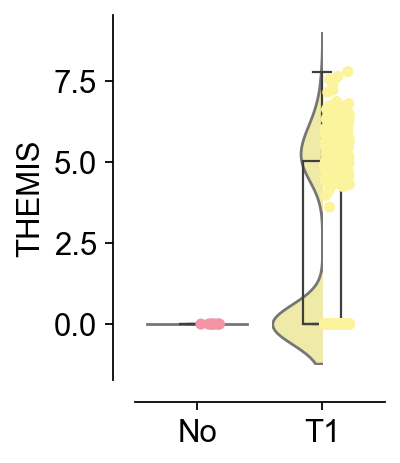

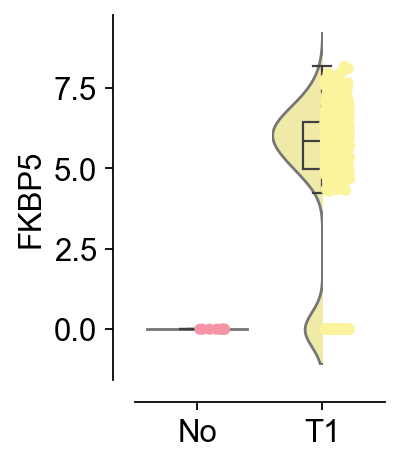

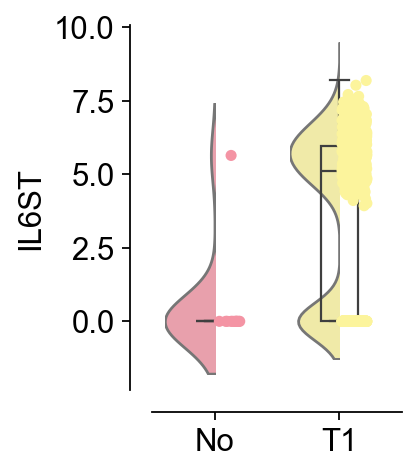

In [40]:
import matplotlib.pyplot as plt

ct='T CD4+'
for gene in ['THEMIS', 'FKBP5', 'IL6ST']:
    fig, ax = plt.subplots(1,1,figsize=(2,3))
    ov.pl.violin_box(adata[adata.obs['best_celltype']==ct],gene,groupby='CancerStage',ax=ax,
                     show=False
                )
    #ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
     #                 text_y=0.1,
      ##                text='$p={}$'.format(round(deg_results_dict[ct].loc[gene,'qvalue'],3)),
        #              fontsize=11,fontcolor='#000000',
         #                horizontalalignment='center',)
    plt.xlabel('')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))

    plt.savefig(f'figures/sttexp/violin-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')

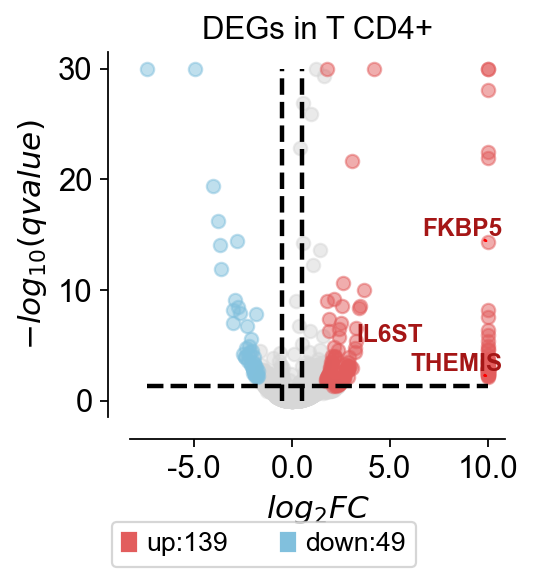

In [43]:
deg_cluster='T CD4+'
ov.pl.volcano(deg_results_dict[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=30,FC_max=10,
                    figsize=(3,3),title=f'DEGs in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['THEMIS', 'FKBP5', 'IL6ST'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


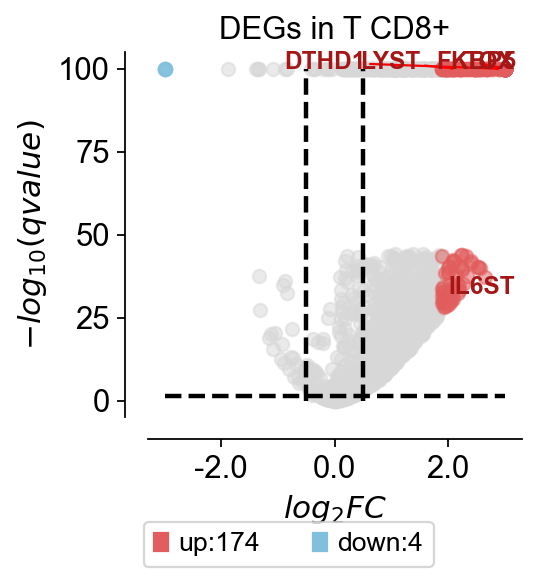

In [48]:
deg_cluster='T CD8+'
ov.pl.volcano(deg_results_dict[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DEGs in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['FKBP5', 'LYST', 'TOX', 'DTHD1', 'IL6ST'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


In [41]:
ct='Plasma cell'
deg_results_dict[ct]['pq']=deg_results_dict[ct]['-log(qvalue)']
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'pq']=\
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'pq']+\
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'BaseMean']

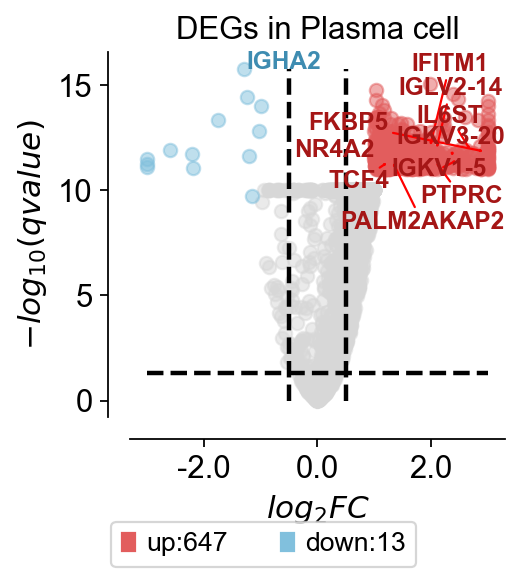

In [45]:
deg_cluster='Plasma cell'
volcano(deg_results_dict[deg_cluster],pval_name='pq',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DEGs in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['IGKV1-5', 'IGKV3-20', 'FKBP5', 'IGLV2-14', 'IL6ST',
            'PTPRC', 'IGHA2', 'TCF4', 'PALM2AKAP2', 'IFITM1', 'NR4A2'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


In [19]:
ct='Gastric foveolar cell'
deg_results_dict[ct]['sig']='normal'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']>1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='up'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']<-1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='down'

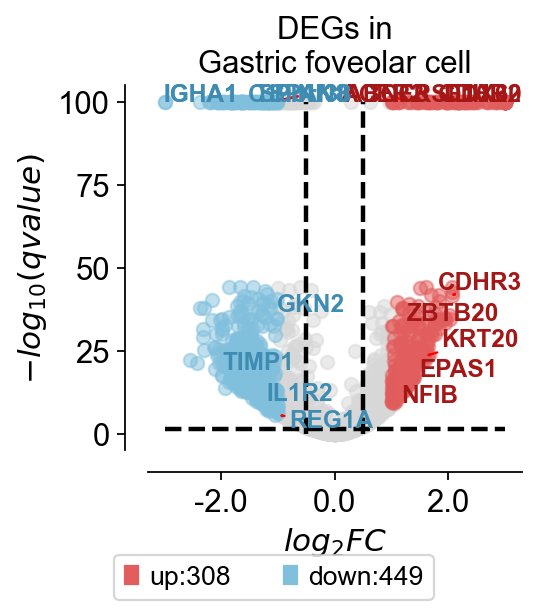

In [20]:
deg_cluster='Gastric foveolar cell'
ov.pl.volcano(deg_results_dict[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DEGs in\n{deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['REG1A',
 'TIMP1',
 'ACER2',
 'ABCC3',
 'SPINK1',
 'TNFRSF10D',
 'GKN2',
 'TSPAN8',
 'C19orf33',
 'EPAS1',
 'KRT20',
 'CDHR2',
 'NFIB',
 'IGHA1',
 'ZBTB20',
 'IL1R2',
 'CDHR3','IGHA1','DDX60'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


In [21]:
ct='Enterocyte'
deg_results_dict[ct]['sig']='normal'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']>1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='up'
deg_results_dict[ct].loc[(deg_results_dict[ct]['log2FC']<-1)&\
(deg_results_dict[ct]['qvalue']<0.05),'sig']='down'

In [33]:
deg_results_dict[ct]['pq']=deg_results_dict[ct]['-log(qvalue)']
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'pq']=\
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'pq']+\
deg_results_dict[ct].loc[(deg_results_dict[ct]['-log(qvalue)']>=10)&(deg_results_dict[ct]['sig']!='normal'),'BaseMean']

In [34]:
deg_results_dict[ct]

,pvalue,qvalue,FoldChange,MaxBaseMean,BaseMean,log2(BaseMean),log2FC,abs(log2FC),size,-log(pvalue),-log(qvalue),sig,pq
NOC2L,0.000000e+00,0.000000e+00,2.063700,1.580500,1.173119,0.230349,1.045233,1.045233,0.206370,inf,10.000000,up,11.173119
ISG15,8.006067e-39,2.613582e-38,0.588965,2.164491,1.719602,0.782075,-0.763747,0.763747,0.058896,38.096581,10.000000,normal,10.000000
UBE2J2,1.564351e-39,5.124158e-39,1.771356,1.483295,1.160286,0.214480,0.824854,0.824854,0.177136,38.805664,10.000000,normal,10.000000
INTS11,3.990573e-39,1.305262e-38,1.666962,1.707523,1.365881,0.449832,0.737221,0.737221,0.166696,38.398964,10.000000,normal,10.000000
AURKAIP1,6.431296e-06,1.336959e-05,1.061180,4.568046,4.436358,2.149376,0.085670,0.085670,0.106118,5.191701,4.873882,normal,4.873882
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,3.664169e-07,7.952043e-07,0.913986,3.766835,3.604824,1.849929,-0.129757,0.129757,0.091399,6.436025,6.099521,normal,6.099521
MT-ND4,1.566215e-19,4.328224e-19,1.022463,8.585414,8.491104,3.085952,0.032048,0.032048,0.102246,18.805149,10.000000,normal,10.000000
MT-ND5,2.295890e-01,3.141084e-01,0.993384,6.295897,6.275068,2.649631,-0.009577,0.009577,0.099338,0.639049,0.502920,normal,0.502920
MT-ND6,2.606397e-01,3.523445e-01,0.945705,1.081030,1.051676,0.072691,-0.080538,0.080538,0.094571,0.583960,0.453032,normal,0.453032


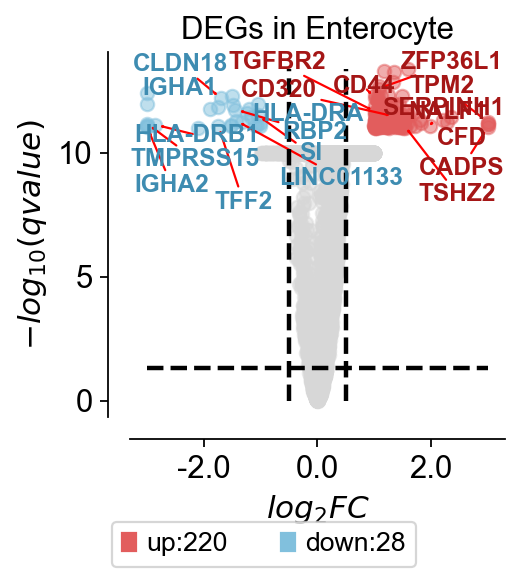

In [35]:
deg_cluster='Enterocyte'

volcano(deg_results_dict[deg_cluster],pval_name='pq',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=20,FC_max=3,
                    figsize=(3,3),title=f'DEGs in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['TGFBR2',
 'IGHA1',
 'TFF2',
 'TSHZ2',
 'HLA-DRA',
 'CLDN18',
 'SI',
 'IGHA2',
 'LINC01133',
 'CD44',
 'ZFP36L1',
 'CD320',
 'CFD',
 'SERPINH1',
 'NALF1',
 'TPM2',
 'TMPRSS15',
 'CADPS',
 'HLA-DRB1',
 'RBP2'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


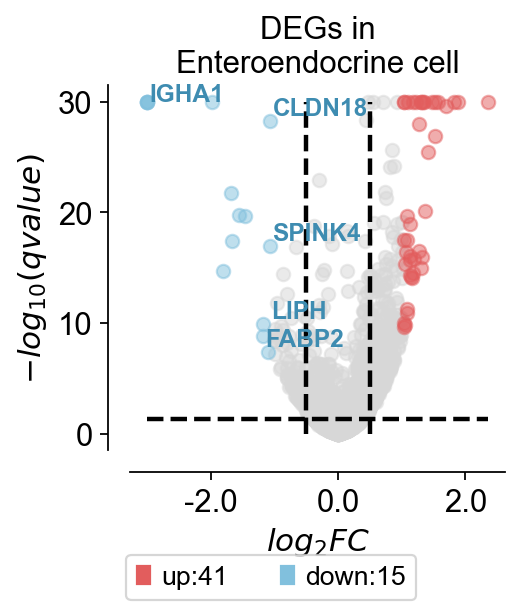

In [57]:
deg_cluster='Enteroendocrine cell'
ov.pl.volcano(deg_results_dict[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=30,FC_max=3,
                    figsize=(3,3),title=f'DEGs in\n{deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     plot_genes=['IGHA1', 'SPINK4', 'FABP2', 'CLDN18', 'LIPH'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/stt/gc_gas_deg_{deg_cluster}-33.png',dpi=300,bbox_inches='tight')


In [30]:
import numpy as np
import pandas as pd
import scanpy as sc
import statsmodels.api as sm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib

def volcano(result,pval_name='qvalue',fc_name='log2FC',pval_max=None,FC_max=None,
            figsize:tuple=(4,4),title:str='',titlefont:dict={'weight':'normal','size':14,},
                     up_color:str='#e25d5d',down_color:str='#7388c1',normal_color:str='#d7d7d7',
                     up_fontcolor:str='#e25d5d',down_fontcolor:str='#7388c1',normal_fontcolor:str='#d7d7d7',
                     legend_bbox:tuple=(0.8, -0.2),legend_ncol:int=2,legend_fontsize:int=12,
                     plot_genes:list=None,plot_genes_num:int=10,plot_genes_fontsize:int=10,
                     ticks_fontsize:int=12,pval_threshold:float=0.05,fc_max:float=1.5,fc_min:float=-1.5,
                     ax = None,):
    result=result.copy()
    result['-log(qvalue)']=result[pval_name]
    #-np.log10(result[pval_name])
    result['log2FC']= result[fc_name].copy()
    if pval_max!=None:
        result.loc[result['-log(qvalue)']>pval_max,'-log(qvalue)']=pval_max
    if FC_max!=None:
        result.loc[result['log2FC']>FC_max,'log2FC']=FC_max
        result.loc[result['log2FC']<-FC_max,'log2FC']=0-FC_max
    
    if ax==None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(x=result[result['sig']=='normal']['log2FC'],
            y=result[result['sig']=='normal']['-log(qvalue)'],
            color=normal_color,#颜色
            alpha=.5,#透明度
            )
    #接着绘制上调基因
    ax.scatter(x=result[result['sig']=='up']['log2FC'],
            y=result[result['sig']=='up']['-log(qvalue)'],
            color=up_color,#选择色卡第15个颜色
            alpha=.5,#透明度
            )
    #绘制下调基因
    ax.scatter(x=result[result['sig']=='down']['log2FC'],
            y=result[result['sig']=='down']['-log(qvalue)'],
            color=down_color,#颜色
            alpha=.5,#透明度
            )

    ax.plot([result['log2FC'].min(),result['log2FC'].max()],#辅助线的x值起点与终点
            [-np.log10(pval_threshold),-np.log10(pval_threshold)],#辅助线的y值起点与终点
            linewidth=2,#辅助线的宽度
            linestyle="--",#辅助线类型：虚线
            color='black'#辅助线的颜色
    )
    ax.plot([fc_max,fc_max],
            [result['-log(qvalue)'].min(),result['-log(qvalue)'].max()],
            linewidth=2, 
            linestyle="--",
            color='black')
    ax.plot([fc_min,fc_min],
            [result['-log(qvalue)'].min(),result['-log(qvalue)'].max()],
            linewidth=2, 
            linestyle="--",
            color='black')
    #设置横标签与纵标签
    ax.set_ylabel(r'$-log_{10}(qvalue)$',titlefont)                                    
    ax.set_xlabel(r'$log_{2}FC$',titlefont)
    #设置标题
    ax.set_title(title,titlefont)

    #绘制图注
    #legend标签列表，上面的color即是颜色列表
    labels = ['up:{0}'.format(len(result[result['sig']=='up'])),
            'down:{0}'.format(len(result[result['sig']=='down']))]  
    #用label和color列表生成mpatches.Patch对象，它将作为句柄来生成legend
    color = [up_color,down_color]
    patches = [mpatches.Patch(color=color[i], label="{:s}".format(labels[i]) ) for i in range(len(color))] 

    ax.legend(handles=patches,
        bbox_to_anchor=legend_bbox, 
        ncol=legend_ncol,
        fontsize=legend_fontsize)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)

    ax.set_xticks([round(i,2) for i in ax.get_xticks()[1:-1]],#获取x坐标轴内容
        [round(i,2) for i in ax.get_xticks()[1:-1]],#更新x坐标轴内容
        fontsize=ticks_fontsize,
        fontweight='normal'
        )

    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))


    from adjustText import adjust_text
    import adjustText

    if plot_genes is not None:
        hub_gene=plot_genes
    elif (plot_genes is None) and (plot_genes_num is None):
        return ax
    else:
        up_result=result.loc[result['sig']=='up']
        down_result=result.loc[result['sig']=='down']
        hub_gene=up_result.sort_values(pval_name).index[:plot_genes_num//2].tolist()+down_result.sort_values(pval_name).index[:plot_genes_num//2].tolist()

    color_dict={
    'up':up_fontcolor,
        'down':down_fontcolor,
        'normal':normal_fontcolor
    }

    texts=[ax.text(result.loc[i,'log2FC'], 
        result.loc[i,'-log(qvalue)'],
        i,
        fontdict={'size':plot_genes_fontsize,'weight':'bold','color':color_dict[result.loc[i,'sig']]}
        ) for i in hub_gene]

    if adjustText.__version__<='0.8':
        adjust_text(texts,only_move={'text': 'xy'},arrowprops=dict(arrowstyle='->', color='red'),)
    else:
        adjust_text(texts,only_move={"text": "xy", "static": "xy", "explode": "xy", "pull": "xy"},
                    arrowprops=dict(arrowstyle='->', color='red'))

    
    return ax

def venn(sets={}, out='./', palette='bgrc',
             ax=False, ext='png', dpi=300, fontsize=3.5):
    
    from ..utils import venny4py
    venny4py(sets=sets,out=out,ce=palette,asax=ax,ext=ext,
             dpi=dpi,size=fontsize)
    return ax

def boxplot(data,hue,x_value,y_value,width=0.6,title='',
                 figsize=(6,3),palette=None,fontsize=10,
                 legend_bbox=(1, 0.55),legend_ncol=1,):
    """
    Plots a boxplot with jittered points.

    Parameters
    ----------
    - data : `pandas.DataFrame`
        Dataframe containing the data to plot.
    - hue : `str`
        Column name of the dataframe containing the hue data.
    - x_value : `str`
        Column name of the dataframe containing the x-axis data.
    - y_value : `str`
        Column name of the dataframe containing the y-axis data.
    - width : `float`, optional
        Width of the boxplot, by default 0.6.
    - title : `str`, optional
        Title of the plot, by default ''.
    - figsize : `tuple`, optional
        Size of the figure, by default (6,3).
    - palette : `list`, optional
        List of colors to use for the plot, by default None.
    - fontsize : `int`, optional
        Font size of the plot, by default 10.
    - legend_bbox : `tuple`, optional
        Bounding box of the legend, by default (1, 0.55).
    - legend_ncol : `int`, optional
        Number of columns in the legend, by default 1.

    Returns
    -------
    - fig: `matplotlib.figure.Figure`
        Figure object.
    - ax: `matplotlib.axes._subplots.AxesSubplot`
        Axes object.
    """

    #获取需要分割的数据
    hue=hue
    hue_datas=list(set(data[hue]))

    #获取箱线图的横坐标
    x=x_value
    ticks=list(set(data[x]))

    #在这个数据中，我们有6个不同的癌症，每个癌症都有2个基因（2个箱子）
    #所以我们需要得到每一个基因的6个箱线图位置，6个散点图的抖动
    plot_data1={}#字典里的每一个元素就是每一个基因的所有值
    plot_data_random1={}#字典里的每一个元素就是每一个基因的随机20个值
    plot_data_xs1={}#字典里的每一个元素就是每一个基因的20个抖动值


    #箱子的参数
    #width=0.6
    y=y_value
    from ..utils import ticks_range
    import random
    for hue_data,num in zip(hue_datas,ticks_range(len(hue_datas),width)):
        data_a=[]
        data_a_random=[]
        data_a_xs=[]
        for i,k in zip(ticks,range(len(ticks))):
            test_data=data.loc[((data[x]==i)&(data[hue]==hue_data)),y].tolist()
            data_a.append(test_data)
            if len(test_data)<20:
                data_size=len(test_data)
            else:
                data_size=20
            random_data=random.sample(test_data,data_size)
            data_a_random.append(random_data)
            data_a_xs.append(np.random.normal(k*len(hue_datas)+num, 0.04, len(random_data)))
        #data_a=np.array(data_a)
        data_a_random=np.array(data_a_random)
        plot_data1[hue_data]=data_a 
        plot_data_random1[hue_data]=data_a_random
        plot_data_xs1[hue_data]=data_a_xs

    fig, ax = plt.subplots(figsize=figsize)
    #色卡
    if palette==None:
        from ._palette import sc_color
        palette=sc_color
    #palette=["#a64d79","#674ea7"]
    #绘制箱线图
    for hue_data,hue_color,num in zip(hue_datas,palette,ticks_range(len(hue_datas),width)):
        b1=ax.boxplot(plot_data1[hue_data], 
                    positions=np.array(range(len(ticks)))*len(hue_datas)+num, 
                    sym='', 
                    widths=width,)
        plt.setp(b1['boxes'], color=hue_color)
        plt.setp(b1['whiskers'], color=hue_color)
        plt.setp(b1['caps'], color=hue_color)
        plt.setp(b1['medians'], color=hue_color)

        clevels = np.linspace(0., 1., len(plot_data_random1[hue_data]))
        for x, val, clevel in zip(plot_data_xs1[hue_data], plot_data_random1[hue_data], clevels):
            plt.scatter(x, val,c=hue_color,alpha=0.4)

    #坐标轴字体
    #fontsize=10
    #修改横坐标
    ax.set_xticks(range(0, len(ticks) * len(hue_datas), len(hue_datas)), ticks,fontsize=fontsize)
    #修改纵坐标
    yticks=ax.get_yticks()
    ax.set_yticks(yticks[yticks>=0],yticks[yticks>=0],fontsize=fontsize)

    labels = hue_datas  #legend标签列表，上面的color即是颜色列表
    color = palette
    #用label和color列表生成mpatches.Patch对象，它将作为句柄来生成legend
    patches = [ mpatches.Patch(color=color[i], label="{:s}".format(labels[i]) ) for i in range(len(hue_datas)) ] 
    ax.legend(handles=patches,bbox_to_anchor=legend_bbox, ncol=legend_ncol,fontsize=fontsize)

    #设置标题
    ax.set_title(title,fontsize=fontsize+1)
    #设置spines可视化情况
    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    
    return fig,ax